# 01 — Dataset Exploration & Preprocessing

## Driver Drowsiness Detection

This notebook is the **first stage** of the project. It prepares the dataset that will be used by the Custom CNN and MobileNetV2 notebooks.

### Tasks
- Inspect the dataset
- Count images in each class
- Visualize samples
- Check image dimensions and corrupt files
- Create a stratified 70/15/15 train-validation-test split
- Resize images to 224 × 224
- Normalize pixel values
- Apply training-only data augmentation
- Save split metadata for the next notebooks

### Classes
- `Closed`
- `Open`
- `no_yawn`
- `yawn`


## 1. Import Libraries

In [14]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow version: 2.21.0
Available GPUs: []


## 2. Project Configuration

Because this notebook is stored inside the `notebooks` folder, the expected dataset path is:

`../dataset/train/`


In [15]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

CLASS_NAMES = ["Closed", "Open", "no_yawn", "yawn"]

DATA_DIR = Path("../dataset/train")

# Fallback if the notebook is opened/run from the project root.
if not DATA_DIR.exists():
    DATA_DIR = Path("dataset/train")

print("Dataset path:", DATA_DIR.resolve())
print("Dataset exists:", DATA_DIR.exists())

if not DATA_DIR.exists():
    raise FileNotFoundError(
        "Dataset not found. Expected dataset/train/ containing "
        "Closed, Open, no_yawn and yawn folders."
    )


Dataset path: D:\driver-drowsiness-detection\dataset\train
Dataset exists: True


## 3. Verify Dataset Structure

In [16]:
for class_name in CLASS_NAMES:
    class_dir = DATA_DIR / class_name

    if class_dir.exists():
        files = [p for p in class_dir.iterdir() if p.is_file()]
        print(f"{class_name:10} : {len(files)} images")
    else:
        print(f"{class_name:10} : FOLDER NOT FOUND")


Closed     : 726 images
Open       : 726 images
no_yawn    : 725 images
yawn       : 723 images


## 4. Create Dataset DataFrame

Each image is represented by its file path, class name, and numerical label.


In [17]:
records = []

for label, class_name in enumerate(CLASS_NAMES):
    class_dir = DATA_DIR / class_name

    for file_path in class_dir.iterdir():
        if file_path.is_file():
            records.append({
                "filepath": str(file_path.resolve()),
                "class_name": class_name,
                "label": label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))
display(df.head())


Total images: 2900


,filepath,class_name,label
0,D:\driver-drowsiness-detection\dataset\train\C...,Closed,0
1,D:\driver-drowsiness-detection\dataset\train\C...,Closed,0
2,D:\driver-drowsiness-detection\dataset\train\C...,Closed,0
3,D:\driver-drowsiness-detection\dataset\train\C...,Closed,0
4,D:\driver-drowsiness-detection\dataset\train\C...,Closed,0


## 5. Class Distribution

In [18]:
class_counts = (
    df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES)
    .fillna(0)
    .astype(int)
)

display(class_counts.to_frame("Image Count"))


,Image Count
class_name,
Closed,726
Open,726
no_yawn,725
yawn,723


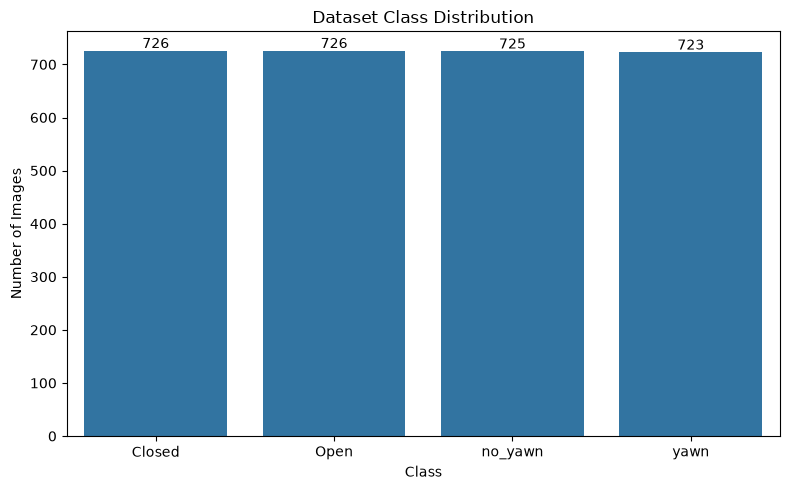

In [19]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

for i, value in enumerate(class_counts.values):
    ax.text(i, value + 5, str(value), ha="center")

plt.tight_layout()
plt.show()


## 6. Check Dataset Balance

In [20]:
balance_ratio = class_counts.min() / class_counts.max()

print(f"Minimum / Maximum class ratio: {balance_ratio:.3f}")

if balance_ratio >= 0.80:
    print("Result: The dataset is reasonably balanced.")
else:
    print("Result: The dataset has noticeable class imbalance.")


Minimum / Maximum class ratio: 0.996
Result: The dataset is reasonably balanced.


## 7. Inspect Image Dimensions

In [21]:
dimension_records = []

for file_path in df["filepath"]:
    try:
        with Image.open(file_path) as img:
            dimension_records.append({
                "filepath": file_path,
                "width": img.width,
                "height": img.height,
                "mode": img.mode
            })
    except Exception as error:
        dimension_records.append({
            "filepath": file_path,
            "width": None,
            "height": None,
            "mode": f"ERROR: {error}"
        })

dimensions_df = pd.DataFrame(dimension_records)

print("Most common image dimensions:")
display(
    dimensions_df
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(20)
)

print("Image modes:")
display(dimensions_df["mode"].value_counts())


Most common image dimensions:


,width,height,count
924,640,480,1448
508,300,300,14
621,342,300,9
693,390,300,7
665,370,300,7
710,400,300,6
588,322,300,6
589,323,300,6
1033,1280,1280,6
557,304,300,6


Image modes:


mode
RGB     2898
RGBA       2
Name: count, dtype: int64

## 8. Check for Corrupt or Unreadable Images

In [22]:
valid_images = []
invalid_images = []

for file_path in df["filepath"]:
    try:
        with Image.open(file_path) as img:
            img.verify()
        valid_images.append(file_path)
    except Exception as error:
        invalid_images.append((file_path, str(error)))

print("Valid images:", len(valid_images))
print("Invalid images:", len(invalid_images))

if invalid_images:
    print("\nFirst invalid files:")
    for item in invalid_images[:10]:
        print(item)
else:
    print("No corrupt images detected.")


Valid images: 2900
Invalid images: 0
No corrupt images detected.


## 9. Visualize Sample Images

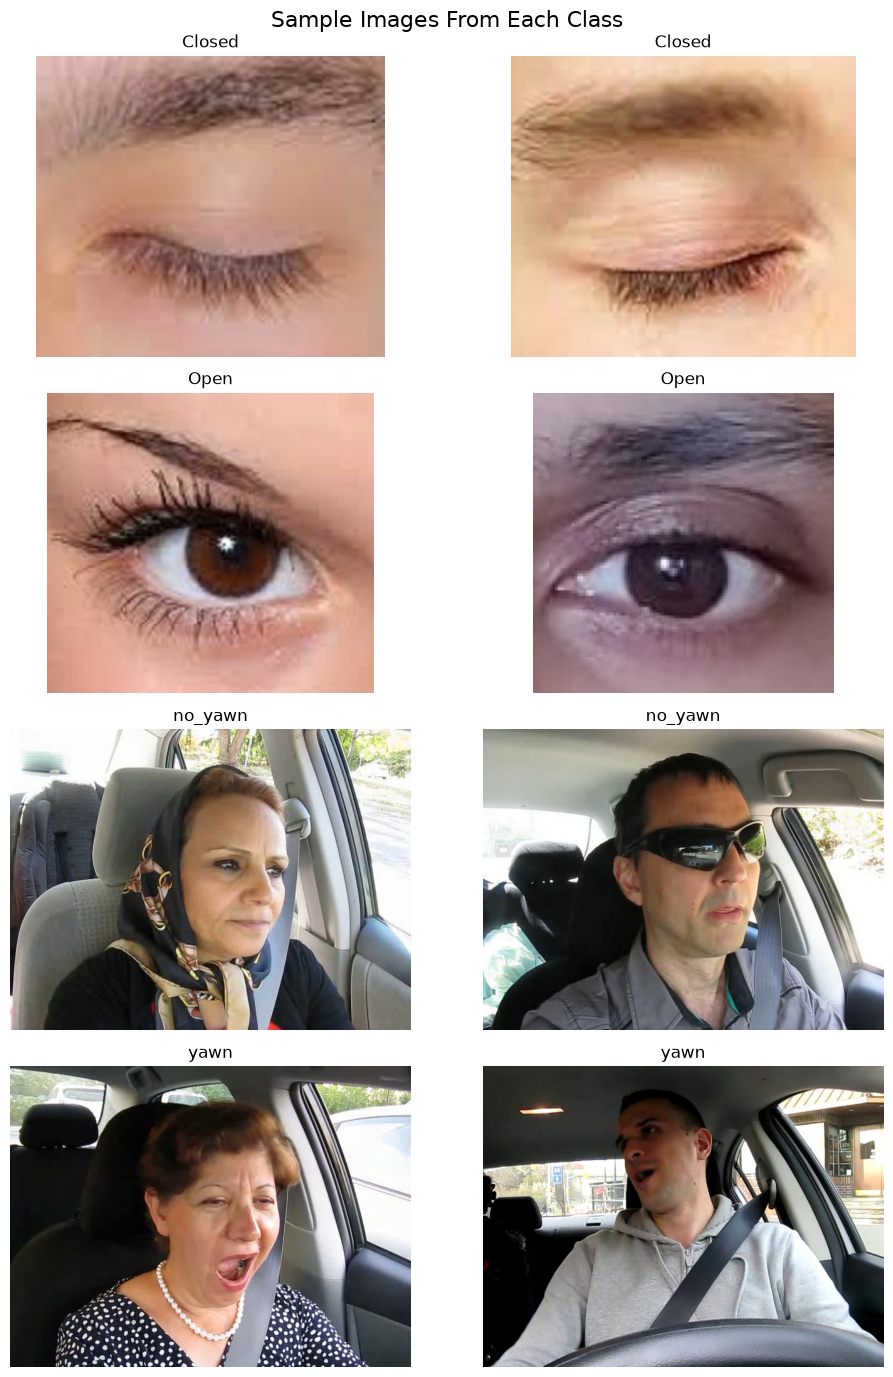

In [23]:
fig, axes = plt.subplots(4, 2, figsize=(10, 14))

for row, class_name in enumerate(CLASS_NAMES):
    class_files = df.loc[
        df["class_name"] == class_name,
        "filepath"
    ].tolist()

    samples = random.sample(class_files, min(2, len(class_files)))

    for col, file_path in enumerate(samples):
        image = Image.open(file_path).convert("RGB")

        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.suptitle("Sample Images From Each Class", fontsize=16)
plt.tight_layout()
plt.show()

## 10. Create Train / Validation / Test Split

The supplied dataset has the images under one `train` directory. We will create a reproducible stratified split:

- **70% Training**
- **15% Validation**
- **15% Test**

Stratification keeps the class distribution approximately consistent across all three datasets.


In [24]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training images  :", len(train_df))
print("Validation images:", len(val_df))
print("Test images      :", len(test_df))
print("Total             :", len(train_df) + len(val_df) + len(test_df))


Training images  : 2030
Validation images: 435
Test images      : 435
Total             : 2900


## 11. Verify Split Distribution

In [25]:
split_distribution = pd.DataFrame({
    "Train": train_df["class_name"].value_counts().reindex(CLASS_NAMES),
    "Validation": val_df["class_name"].value_counts().reindex(CLASS_NAMES),
    "Test": test_df["class_name"].value_counts().reindex(CLASS_NAMES)
}).fillna(0).astype(int)

display(split_distribution)


,Train,Validation,Test
class_name,,,
Closed,508,109,109
Open,508,109,109
no_yawn,508,109,108
yawn,506,108,109


In [26]:
split_percentages = (
    split_distribution
    .div(split_distribution.sum(axis=0), axis=1)
    * 100
)

display(split_percentages.round(2))


,Train,Validation,Test
class_name,,,
Closed,25.02,25.06,25.06
Open,25.02,25.06,25.06
no_yawn,25.02,25.06,24.83
yawn,24.93,24.83,25.06


## 12. Visualize Train / Validation / Test Distribution

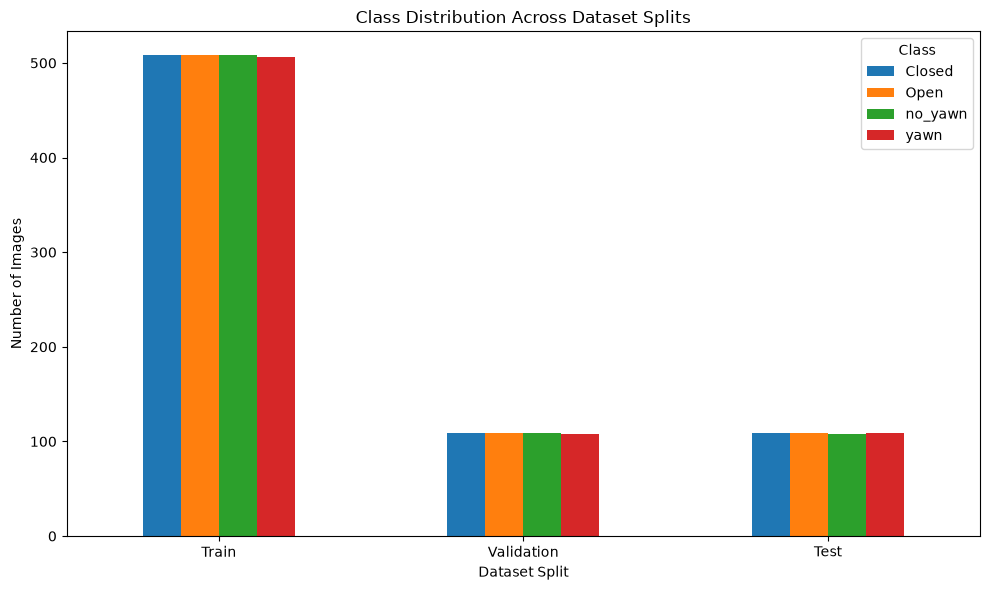

In [27]:
split_distribution.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Class Distribution Across Dataset Splits")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.legend(title="Class")
plt.tight_layout()
plt.show()


## 13. Image Preprocessing

All images will be:

1. Converted to RGB.
2. Resized to **224 × 224**.
3. Converted to `float32`.
4. Normalized from **0–255 to 0–1**.


In [28]:
def load_image(path, label):
    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label


## 14. Create TensorFlow Dataset Pipeline

In [29]:
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(dataframe, shuffle=False):
    paths = dataframe["filepath"].values
    labels = dataframe["label"].values.astype(np.int32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

print(train_ds)


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


## 15. Verify Preprocessed Images

In [30]:
images, labels = next(iter(train_ds))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("Pixel minimum:", tf.reduce_min(images).numpy())
print("Pixel maximum:", tf.reduce_max(images).numpy())


Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)
Pixel minimum: 0.0
Pixel maximum: 1.0


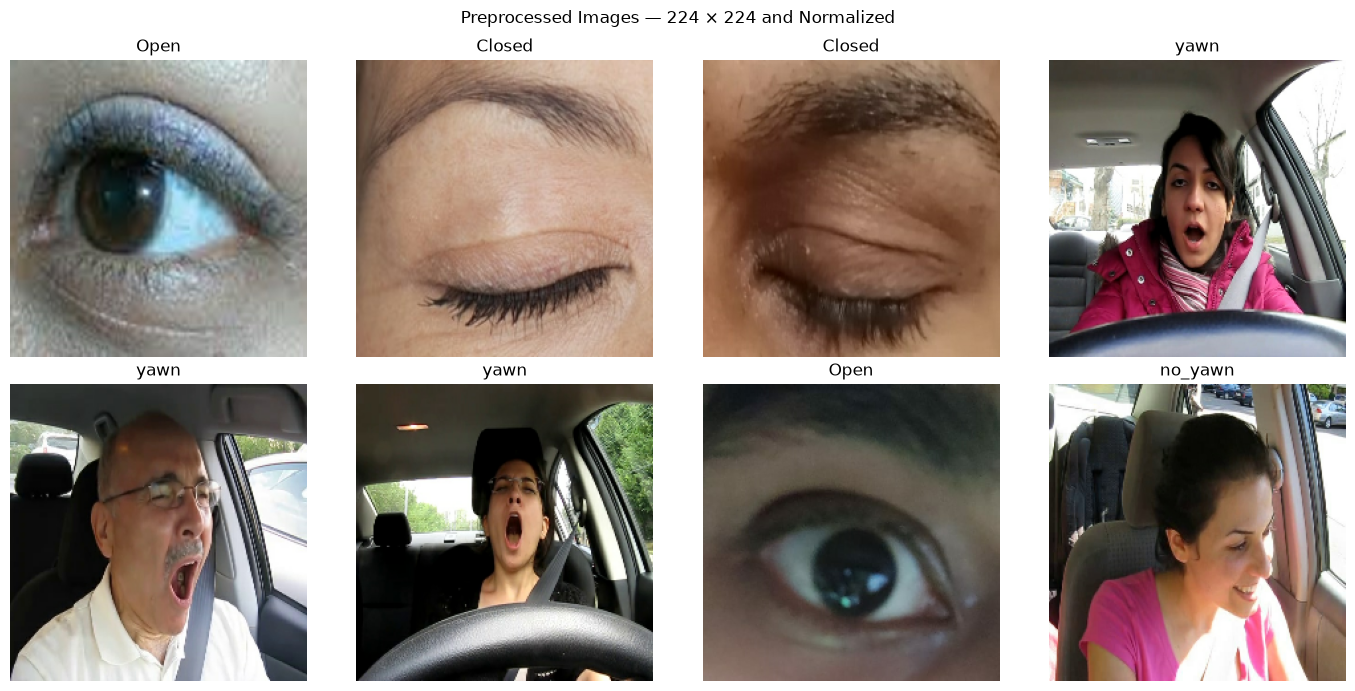

In [31]:
plt.figure(figsize=(14, 7))

for i in range(min(8, len(images))):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(CLASS_NAMES[int(labels[i].numpy())])
    plt.axis("off")

plt.suptitle("Preprocessed Images — 224 × 224 and Normalized")
plt.tight_layout()
plt.show()


## 16. Data Augmentation

Training images will use:

- Horizontal flipping
- Small rotations
- Zoom
- Brightness variation

Validation and test images will **not** be augmented.


In [32]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomBrightness(0.15),
], name="data_augmentation")

data_augmentation


<Sequential name=data_augmentation, built=False>

## 17. Visualize Augmented Images

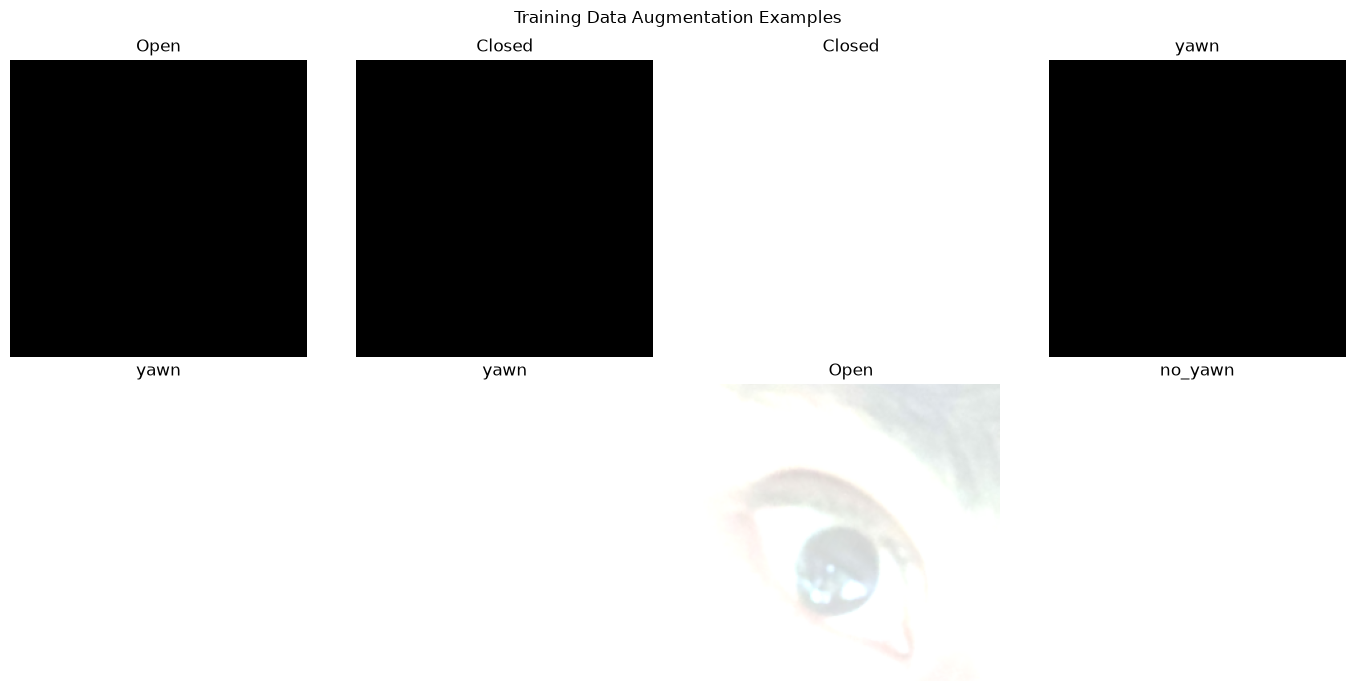

In [33]:
augmented_images = data_augmentation(
    images[:8],
    training=True
)

plt.figure(figsize=(14, 7))

for i in range(8):
    ax = plt.subplot(2, 4, i + 1)

    plt.imshow(
        tf.clip_by_value(
            augmented_images[i],
            0,
            1
        ).numpy()
    )

    plt.title(CLASS_NAMES[int(labels[i].numpy())])
    plt.axis("off")

plt.suptitle("Training Data Augmentation Examples")
plt.tight_layout()
plt.show()


## 18. Save Split Metadata

The original images remain in their existing folders. The CSV files store the exact split assignment so the same images are used consistently in later notebooks.


In [34]:
OUTPUT_DIR = Path("../outputs")

if not OUTPUT_DIR.exists():
    OUTPUT_DIR = Path("outputs")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(
    OUTPUT_DIR / "train_split.csv",
    index=False
)

val_df.to_csv(
    OUTPUT_DIR / "validation_split.csv",
    index=False
)

test_df.to_csv(
    OUTPUT_DIR / "test_split.csv",
    index=False
)

print("Split metadata saved to:", OUTPUT_DIR.resolve())


Split metadata saved to: D:\driver-drowsiness-detection\outputs


## 19. Final Dataset Summary

In [35]:
summary = pd.DataFrame({
    "Dataset": [
        "Original",
        "Training",
        "Validation",
        "Test"
    ],
    "Images": [
        len(df),
        len(train_df),
        len(val_df),
        len(test_df)
    ],
    "Percentage": [
        100,
        len(train_df) / len(df) * 100,
        len(val_df) / len(df) * 100,
        len(test_df) / len(df) * 100
    ]
})

summary["Percentage"] = summary["Percentage"].round(2)

display(summary)


,Dataset,Images,Percentage
0,Original,2900,100.0
1,Training,2030,70.0
2,Validation,435,15.0
3,Test,435,15.0


## 20. Completion Checklist

After running all cells, this notebook should have successfully completed:

- [x] Dataset structure inspection
- [x] Class distribution analysis
- [x] Image dimension analysis
- [x] Corrupt image check
- [x] Sample image visualization
- [x] 70/15/15 stratified split
- [x] 224 × 224 image resizing
- [x] 0–1 pixel normalization
- [x] Horizontal flip augmentation
- [x] Rotation augmentation
- [x] Zoom augmentation
- [x] Brightness augmentation
- [x] TensorFlow dataset creation
- [x] Split metadata saved

### Next Notebook

Once this notebook runs successfully, we will create:

**`02_custom_cnn.ipynb`**

That notebook will build, train, evaluate, and save the Custom CNN model.
